# Clustering Spotify songs using audio features

In this activity, I will try to cluster a real-world dataset, showing the possible result that we can obtain with the K-Means algorithm and possibly offering a critical analysis about the clustering produced. The notebook focuses on grouping Spotify songs based on their audio features (e.g., danceability, energy, acousticness) to identify underlying patterns in the data. In fact, by grouping songs with similar audio characteristics we hope to show that we can easily create music playlists based on a certain mood. This analysis will help us understand how the data is put together and if K-Means is a good tool for finding meaningful music groups.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.manifold import TSNE

## Dataset and feature selection

The dataset I choose contains approximately 1000 of the most streamed Spotify songs in 2023. As we can see the dataset has a lot of features that we are not interested in, so I selected only a subset of features. The features that I want to focus on are the following audio features:

- bpm: Beats per minute, a measure of song tempo
- danceability_%: Percentage indicating how suitable the song is for dancing
- valence_%: Positivity of the song's musical content
- energy_%: Perceived energy level of the song
- acousticness_%: Amount of acoustic sound in the song
- instrumentalness_%: Amount of instrumental content in the song
- liveness_%: Presence of live performance elements
- speechiness_%: Amount of spoken words in the song

Note that the dataset also provide other two more categorical audio features:
- key: Key of the song
- mode: Mode of the song (major or minor)

After studying a little bit how song's key works, I understood that musical keys have a circular relationship (like the Circle of Fifths), so a standard label encoding would impose a misleading linear order, and the one-hot encoding would add a lot of new sparse dimensions. For simplicity, and to ensure the clustering primarily relies on the continuous acoustic properties, these two features were not selected for the analysis.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/top-spotify-songs-2023")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'top-spotify-songs-2023' dataset.
Path to dataset files: /kaggle/input/top-spotify-songs-2023


In [ ]:
df = pd.read_csv("/kaggle/input/top-spotify-songs-2023/spotify-2023.csv", encoding='ISO-8859-1')
print(df.shape)
df.head()

(953, 24)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [ ]:
df.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
audio_features = ['bpm', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
X = df[audio_features]
X.head()

,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,125,80,89,83,31,0,8,4
1,92,71,61,74,7,0,10,4
2,138,51,32,53,17,0,31,6
3,170,55,58,72,11,0,11,15
4,144,65,23,80,14,63,11,6


We can check if we have some missing values. But we don't actually.

In [ ]:
print(X.isnull().sum())

bpm                   0
danceability_%        0
valence_%             0
energy_%              0
acousticness_%        0
instrumentalness_%    0
liveness_%            0
speechiness_%         0
dtype: int64


In [ ]:
X.shape

(953, 8)

Before proceeding with clustering we can plot the distribution of each feature over the dataset, to check the features range and also to check if we can spot some outliers.

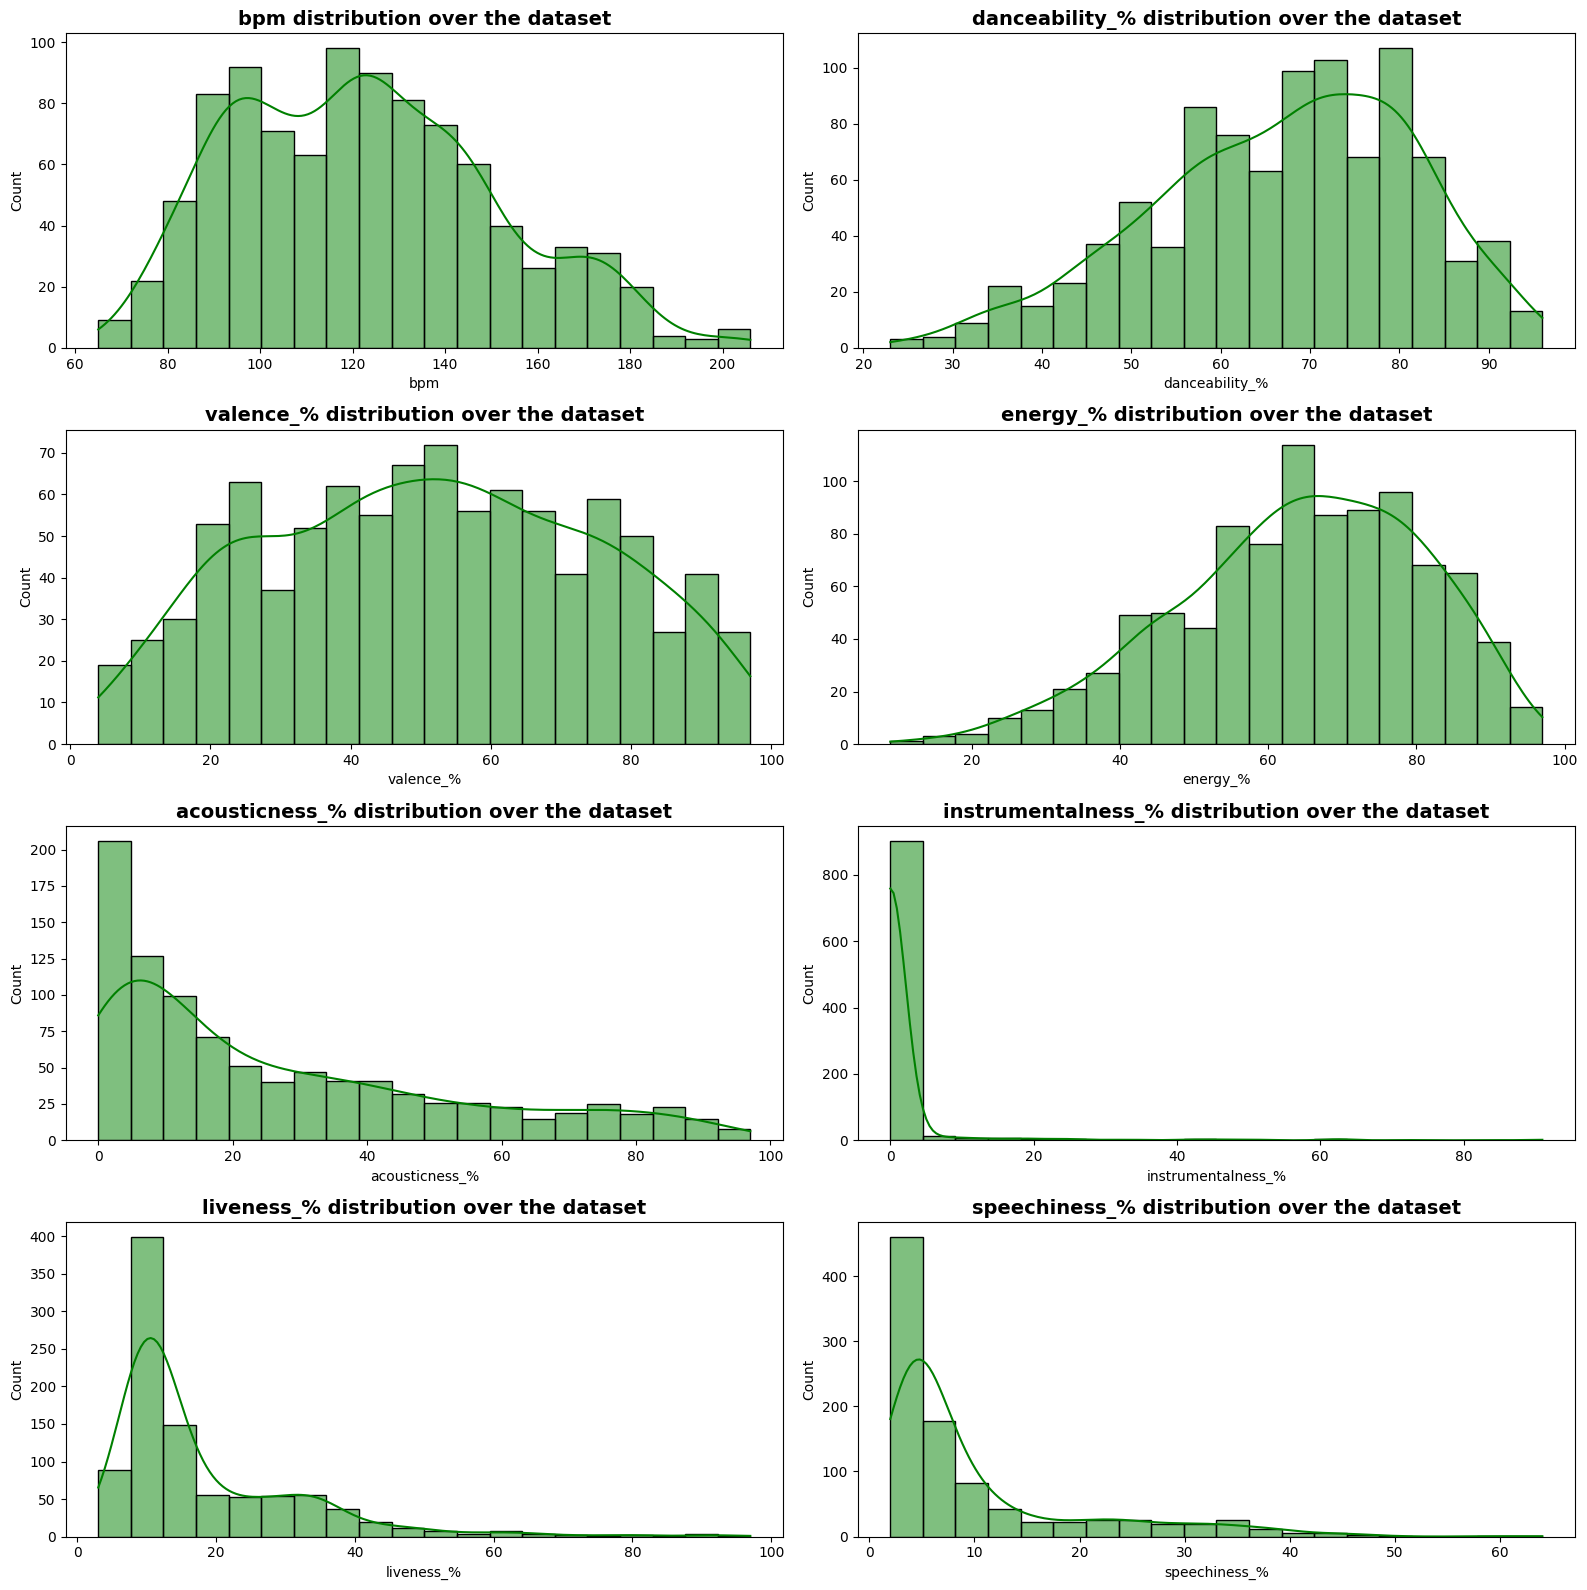

In [ ]:
fig, axs = plt.subplots(4, 2, sharey=False, tight_layout=True, figsize=(16,16))
for i, col in enumerate(audio_features):
  ax = sns.histplot(data=X, x=col, kde=True, color='green', bins=20, ax=axs[i // 2, i % 2])
  ax.set_title(f"{col} distribution over the dataset", fontsize=14, weight = "bold")

plt.show()

We can definitely spot some outliers in some of the chart ahead, obviously having outliers can make the task harder for K-Means but we will try to maintain all the song in the dataset. Some of the outliers could represent not errors but instead some genuine, maybe more rare, musical styles.

Since K-Means relies on distance calculations to determine how close data points are to each other and to the cluster centroids we need to prevent the so called "feature dominance" where features with a large scale will contribute far more to the total distance than features with a small scale. In this dataset we don't have very different range of values for the features, but for example "bpm" has a wider range than all other features, so it is a good idea to use a ```StandardScaler``` to:
- Center the data by shifting the mean of each feature to zero.
- Scale the variance by dividing each feature by its standard deviation.

This results in a dataset ```X_scaled``` where every feature has a mean of 0 and a standard deviation of 1.

In [ ]:
X_scaled = StandardScaler().fit_transform(X)

## Clustering with K-Means

We selected the K-Means clustering algorithm for this analysis because it is an effective and computationally efficient method for partitioning a dataset into $K$ distinct clusters. Given that our goal is to identify some patterns within the Spotify song data (e.g., a "high-energy dance" cluster versus a "low-acoustic ballad" cluster), K-Means can be a good choice.

The algorithm partitions data into k clusters by minimizing the distances between points and their cluster centroids.

Actually the objective function that K-Means is trying to minimize is the following:
$$V(X,\gamma)=\sum_{k=1}^K\sum_{i:\gamma(x_i)=k}||\mathbf{x}_i-c_k||^2$$

where $c_k$ is the centroid of $k$-th cluster, and $\gamma$ is the assignment function that maps every examples in $X$ into one of the $K$ clusters.

Its ease of use and quick speed make it a good starting point for exploring patterns in the data.

To select an optimal number of clusters $K$ we can use the elbow method.

The Elbow Method helps by plotting the Within-Cluster Sum of Squares (WCSS) against increasing k values and looking for a point where the improvement slows down, this point is called the "elbow".

WCSS measures the total squared distance between each data point and the centroid of the cluster it belongs to.

$$WCSS = \sum_{k=1}^{K} \sum_{\mathbf{x} \in C_k} ||\mathbf{x} - c_k||^2$$

Where:

$K$ is the number of clusters. $C_k$ is the $k$-th cluster. $\mathbf{x}$ is a data point. $c_k$ is the centroid of cluster $C_k$.

The Elbow Method focuses on two closely related concepts: distortion and inertia. They both refer to the Within-Cluster Sum of Squares (WCSS) but with a small difference in meaning.

Distortion measures the average squared distance between each data point and its assigned cluster center. It's a measure of how well the clusters represent the data.

Inertia is the sum of squared distances of each data point to its closest cluster center. It's essentially the total squared error of the clustering.

A lower inertia or distortion values suggests better clustering.

The point where the decrease begins to slow, the “elbow”, usually indicates the optimal number of clusters.

In [ ]:
# store metrics for further analysis
silhouette_scores = []
distortions = []
inertias = []

K = range(2,15)
for k in K:
    # K-Means Clustering
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Elbow method
    distortions.append(sum(np.min(cdist(X_scaled, kmeans.cluster_centers_, 'euclidean'), axis=1)**2) / X_scaled.shape[0])
    inertias.append(kmeans.inertia_)

    # Silhoutte score
    sil_score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(sil_score)

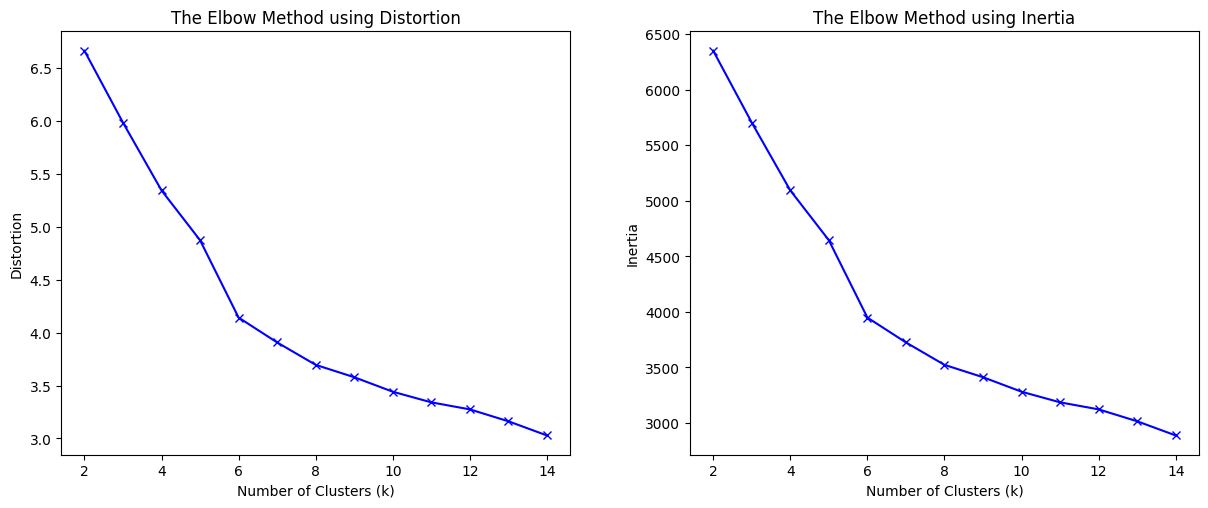

In [ ]:
plt.figure(figsize=(13,6))
plt.subplot(1,2,1)
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.subplot(1,2,2)
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')

plt.tight_layout(pad=4.0)

plt.show()

From the visual plotting using the elbow method a possible number of clusters is 6. But let's use also the Silhoutte Score in order to confirm the possible optimal number of clusters. Obviously we want to avoid a trivial number of cluster (so or too small or too big).

I will not give too much of an explanation about the Silhoutte Score because I already spoke about it in a previous notebook, but shortly if the value is approaching 1 it means excellent separation and compactness. If we have a value near 0 it indicate poor separation, suggesting the clusters are overlapping. And for negative values approaching to -1 it signify that data points have been largely misassigned.

In our case the value is closer to 0 than to 1, so this is an insight that the separation may be not excellent, however before of analyze the result we need to visualize the clustering produced.

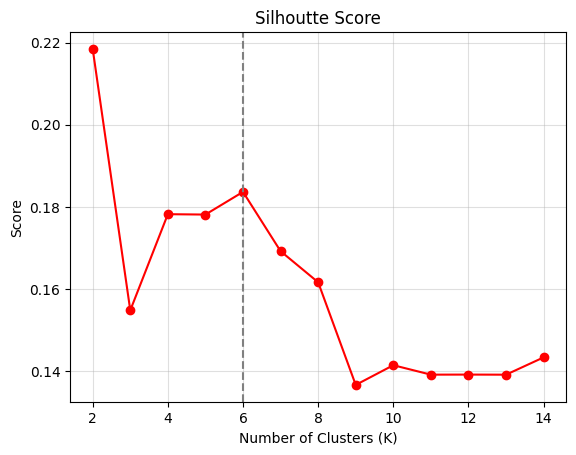

In [ ]:
plt.plot(range(2,15), silhouette_scores, marker='o', linestyle='-', color="red")
plt.axvline(x=6, color='gray', linestyle='--')
plt.title("Silhoutte Score")
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.grid(True, alpha=0.4)
plt.show()

Since also the Silhoutte Score seems to confirm $K=6$ we will try using 6 clusters.

In [ ]:
K = 6

We can add a coloumn to the dataframe to keep track of the cluster in which every example is assigned.

In [ ]:
clustered_data_kmeans = X.copy()
kmeans = KMeans(n_clusters=K, random_state=42)
clustered_data_kmeans['cluster'] = kmeans.fit_predict(X_scaled)

## Showing result using PCA

Since each examples that represent a song has 8 features so we have multi-dimensional representations, we can apply PCA to visualize the data in 3D.

PCA is a linear dimensionality reduction technique that works by transforming the original features into a new set of uncorrelated features called Principal Components.

The primary goal of PCA is to extract the components that capture the maximum possible variance in the data. By selecting the top three Principal Components, we can project the eight-dimensional dataset into a three-dimensional space while retaining as much of the original data's variability as possible.

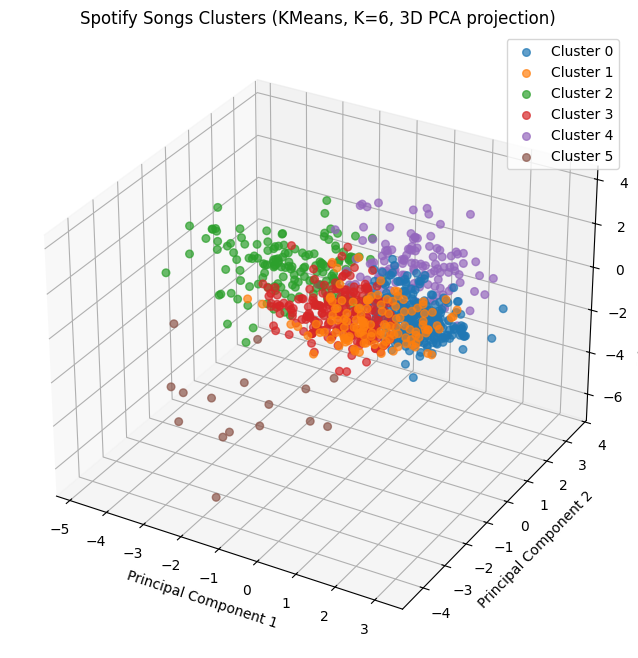

In [ ]:
pca = PCA(n_components=3)
pca_features = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(15, 8))
# Set the projection to '3d'
ax = plt.axes(projection='3d')
cluster_labels = clustered_data_kmeans['cluster']
num_clusters = len(cluster_labels.unique())
palette = sns.color_palette("tab10", num_clusters)

for i in range(num_clusters):
  cluster_data = pca_features[cluster_labels == i]
  ax.scatter(cluster_data[:,0],cluster_data[:,1],cluster_data[:,2],c=[palette[i]], marker='o', s=30, alpha=0.7, label=f"Cluster {i}")

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.legend(loc='upper right')
plt.title("Spotify Songs Clusters (KMeans, K=6, 3D PCA projection)")
plt.show()

This clustering representation may not be very representive of the clusters that was produced in the 8-dimensional original space. In fact, clusters that were actually separate in the original 8-dimensional space may appear merged or heavily overlapping in the 3D plot because the dimensions that separated them were discarded. Also the distances and relationships between the cluster centroids and individual data points may be severely distorted in the 3D projection.

To confirm that maybe this is not a good representation we can analyze the cumulative explained variance ratio, and we can see that the cumulative explained variance ratio for the top three Principal Components is only $\mathbf{53\%}$. This means that nearly half ($\mathbf{47\%}$) of the total variance and information present in the original 8-dimensional audio features space is lost when the data is projected into this 3D PCA space.

However, despite these technical limitations, we can still appreciate a visible subdivision of the clusters, even with some overlapping.

Cumulative Explained Variance Ratio: 0.5358469505154473


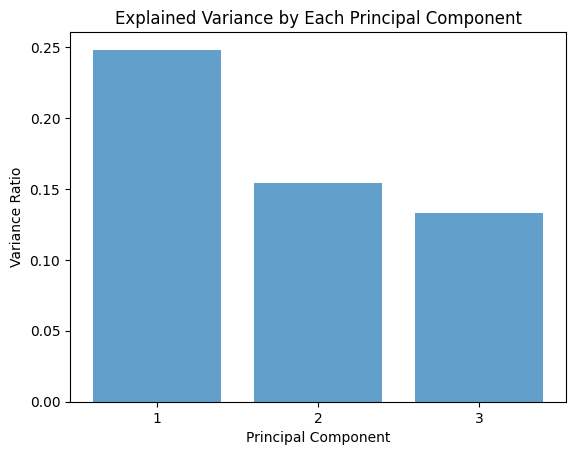

In [ ]:
# Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
print("Cumulative Explained Variance Ratio:", explained_variance.sum())


plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center')
plt.title('Explained Variance by Each Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

## Showing result using t-SNE

To experiment a little more we can also try something else for the visualization like using t-SNE.

Unlike PCA, t-SNE is a non-linear dimensionality reduction technique. It prioritizes keeping similar data points close together and dissimilar points far apart, possibly offering a much clearer picture of the actual cluster separation in a lower dimension. We will try to plot the data in 2D and see the result.


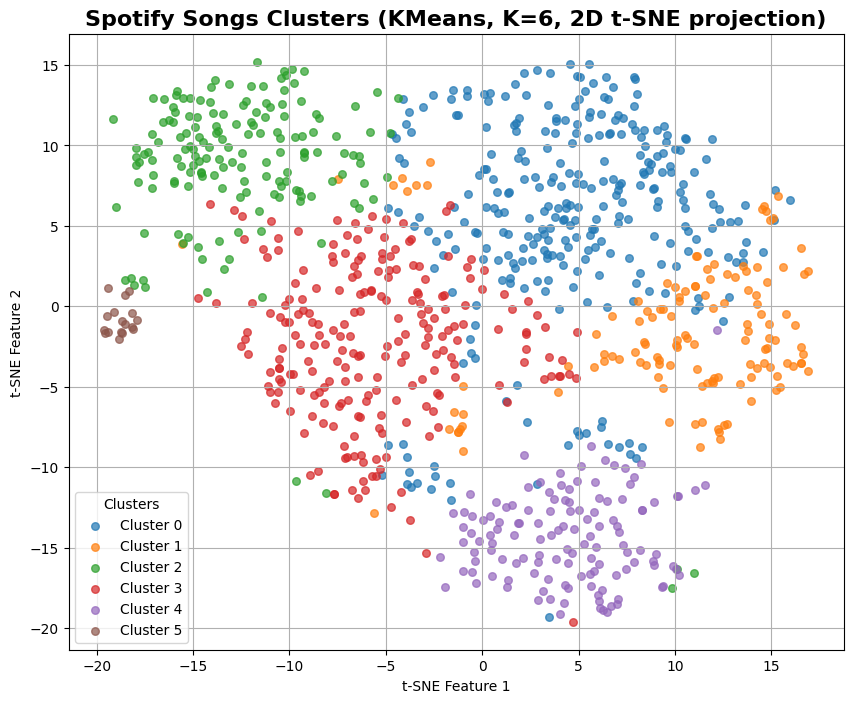

In [ ]:
tsne = TSNE(n_components=2, perplexity=70, random_state=42)
tsne_features = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

for i in range(num_clusters):
    cluster_data = tsne_features[cluster_labels == i]
    ax.scatter(
        cluster_data[:, 0],
        cluster_data[:, 1],
        c=[palette[i]],
        marker='o',
        s=30,
        alpha=0.7,
        label=f"Cluster {i}"
    )

ax.set_xlabel('t-SNE Feature 1')
ax.set_ylabel('t-SNE Feature 2')
ax.legend(title='Clusters', loc='best')
ax.grid(True)
plt.title("Spotify Songs Clusters (KMeans, K=6, 2D t-SNE projection)", fontsize=16, weight='bold')
plt.show()

Even with the use of t-SNE to better visualize the clustering produced, in this 2D visualization we can see that some clusters are not perfectly defined and exhibit some overlap. This outcome, however, is significant as it can reflect the ambiguous nature of musical styles and genres. Rememeber also that even t-SNE is not a perfect representations of the original 8-dimensional space.

Nevertheless, even with some misclassified examples and the presence of overlap, we can visibly spot distinct clusters.

## Meaning of the Clusters and conclusion

To provide a musically meaningful interpretation of the $K=6$ clusters found by the K-Means algorithm, we can analyze the mean value of each audio feature for every cluster. From these mean values, we can derive the dominant characteristics and assign a probable mood or style to each cluster, that will characterize our potential music playlists which was the original idea of this notebook.

In [ ]:
cluster_summary = clustered_data_kmeans.groupby('cluster')[audio_features].mean()
cluster_summary.head(6)

,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
cluster,,,,,,,,
0,116.313993,77.327645,70.464164,71.430034,19.938567,0.320819,12.849829,7.054608
1,116.387597,67.627907,55.620155,73.728682,16.224806,0.069767,43.503876,8.124031
2,118.580247,54.135802,37.092593,42.061728,67.913580,1.345679,16.648148,6.500000
3,134.040179,58.741071,35.848214,66.888393,13.232143,0.892857,13.843750,6.223214
4,127.851562,74.117188,51.609375,62.687500,26.234375,0.078125,15.171875,31.257812
5,122.764706,60.352941,32.235294,58.647059,31.000000,57.411765,14.117647,5.411765


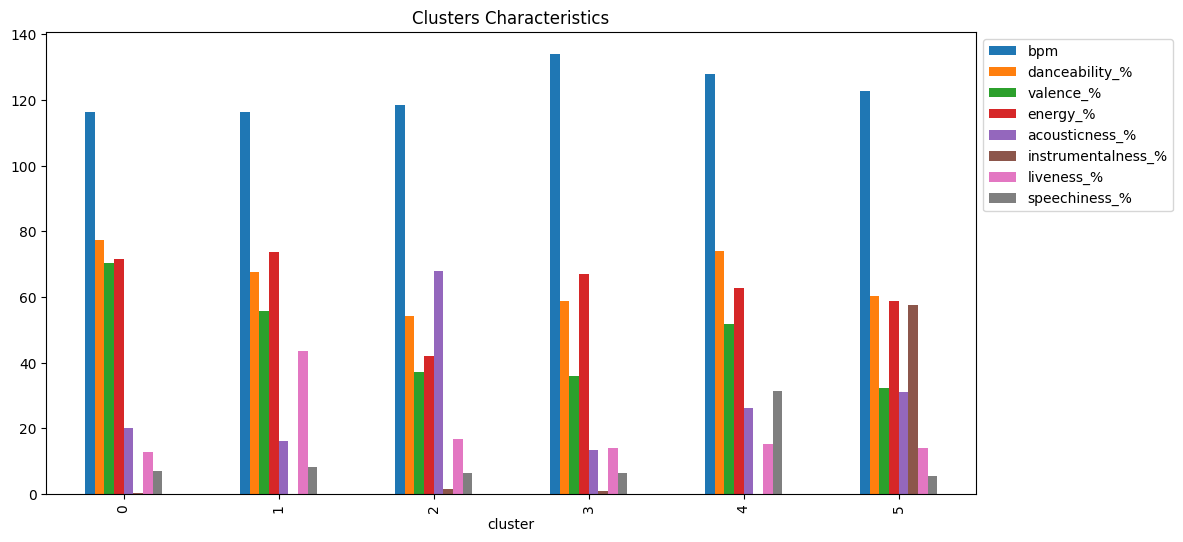

In [ ]:
cluster_summary.plot(kind='bar', figsize=(12, 6))
plt.title('Clusters Characteristics')
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()

In order to assess each cluster I also asked to an LLM to help me classyfing the different clusters:

- Cluster 0: it is characterize by the highest danceability and valence, and has low liveness. They could be songs that are highly encouraging, happy, and perfect for dancing.

- Cluster 1: it has the highest energy but also the highest liveness. These tracks could be live recordings or sound like they're performed on stage.

- Cluster 2: it has very low energy and low valence but very high acousticness. The combination of low energy, low positivity, and high acoustic sound points to slow, sad, or deeply relaxed songs.

- Cluster 3: it is characterize by the highest bpm and also has high energy, the valence is low and the acousticness low. They could be high-intensity electronic, rock, or powerful tracks.

- Cluster 4: with high danceability, very high speechiness and mid-range energy. This cluster could consists of songs dominated by spoken words, such as rap or hip-pop.

- Cluster 5: with very high instrumentalness, low danceability, low valence and mid energy. These tracks could be characterized by a massive proportion of non-vocal content, likely consisting of film scores and ambient tracks.


This clustering is not a simple task, since we don't have any external ground truth provided by the dataset we cannot compute any external metric to evaluate the clustering, therefore the results may be imprecise but I think we could capture some general patterns in the data. Obviously the clustering produced is nowhere near to be perfect, but this could be due to the nature of the data and maybe other clustering technique, different from the K-Means approach that we've used, could achieve a better result.

## Use of AI assistant
I used AI assistant to help me with english language in order to write better some sentences.

## References

Slide Lez14 - Representation Learning

Slide Lez18 - Clustering

https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023/data

https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

https://vtantravahi.medium.com/principal-component-analysis-pca-37dc2c22cdf0

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html